The implementation of **MADDPG** algorithm.

Article Name: **Multi-Agent Actor-Critic for Mixed Cooperative-Competitive Environments**

The link: https://proceedings.neurips.cc/paper_files/paper/2017/hash/68a9750337a418a86fe06c1991a1d64c-Abstract.html

In [1]:
# Cell 1: Environment Setup & Project Directory Creation
!pip install -q mpe2 pettingzoo[mpe] matplotlib imageio imageio-ffmpeg torch

import os

# modular structure in colab
os.makedirs("maddpg_project/src/agents", exist_ok=True)
os.makedirs("maddpg_project/src/buffers", exist_ok=True)
os.makedirs("maddpg_project/src/networks", exist_ok=True)
os.makedirs("maddpg_project/src/utils", exist_ok=True)
os.makedirs("maddpg_project/saved_models", exist_ok=True)
os.makedirs("maddpg_project/renders", exist_ok=True)

print("Project directory structure created successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 668.5/668.5 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 100.8 MB/s eta 0:00:00
Project directory structure created successfully!


In [2]:
%%writefile maddpg_project/src/buffers/buffer.py
import numpy as np
import torch as T

class MultiAgentReplayBuffer:
    def __init__(self, max_size, critic_dims, actor_dims, n_actions, n_agents, batch_size, device='cuda:0'):
        self.mem_size = max_size
        self.mem_cntr = 0
        self.n_agents = n_agents
        self.actor_dims = actor_dims
        self.batch_size = batch_size
        self.n_actions = n_actions
        self.device = device

        self.state_memory = np.zeros((self.mem_size, critic_dims), dtype=np.float32)
        self.new_state_memory = np.zeros((self.mem_size, critic_dims), dtype=np.float32)
        self.reward_memory = np.zeros((self.mem_size, n_agents), dtype=np.float32)
        self.terminal_memory = np.zeros((self.mem_size, n_agents), dtype=bool)

        self.actor_state_memory = [np.zeros((self.mem_size, actor_dims[i]), dtype=np.float32) for i in range(n_agents)]
        self.actor_new_state_memory = [np.zeros((self.mem_size, actor_dims[i]), dtype=np.float32) for i in range(n_agents)]
        self.actor_action_memory = [np.zeros((self.mem_size, n_actions), dtype=np.float32) for i in range(n_agents)]

    def store_transition(self, raw_obs, state, action, reward, raw_obs_, state_, done):
        index = self.mem_cntr % self.mem_size

        for agent_idx in range(self.n_agents):
            self.actor_state_memory[agent_idx][index] = raw_obs[agent_idx]
            self.actor_new_state_memory[agent_idx][index] = raw_obs_[agent_idx]
            self.actor_action_memory[agent_idx][index] = action[agent_idx]

        self.state_memory[index] = state
        self.new_state_memory[index] = state_
        self.reward_memory[index] = reward
        self.terminal_memory[index] = done

        self.mem_cntr += 1

    def sample_buffer(self):
        max_mem = min(self.mem_cntr, self.mem_size)
        batch = np.random.choice(max_mem, self.batch_size, replace=False)

        states = T.tensor(self.state_memory[batch], dtype=T.float32).to(self.device)
        states_ = T.tensor(self.new_state_memory[batch], dtype=T.float32).to(self.device)
        rewards = T.tensor(self.reward_memory[batch], dtype=T.float32).to(self.device)
        terminal = T.tensor(self.terminal_memory[batch], dtype=T.bool).to(self.device)

        actor_states = [T.tensor(self.actor_state_memory[i][batch], dtype=T.float32).to(self.device) for i in range(self.n_agents)]
        actor_new_states = [T.tensor(self.actor_new_state_memory[i][batch], dtype=T.float32).to(self.device) for i in range(self.n_agents)]
        actions = [T.tensor(self.actor_action_memory[i][batch], dtype=T.float32).to(self.device) for i in range(self.n_agents)]

        return actor_states, states, actions, rewards, actor_new_states, states_, terminal

    def ready(self):
        return self.mem_cntr >= self.batch_size

Writing maddpg_project/src/buffers/buffer.py


In [3]:
%%writefile maddpg_project/src/networks/networks.py
import os
import torch as T
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

class ActorNetwork(nn.Module):
    def __init__(self, alpha, input_dims, fc1_dims, fc2_dims, n_actions, name, chkpt_dir):
        super(ActorNetwork, self).__init__()
        self.chkpt_file = os.path.join(chkpt_dir, name)

        self.fc1 = nn.Linear(input_dims, fc1_dims)
        self.fc2 = nn.Linear(fc1_dims, fc2_dims)
        self.pi = nn.Linear(fc2_dims, n_actions)

        self.optimizer = optim.Adam(self.parameters(), lr=alpha)
        self.device = T.device('cuda:0' if T.cuda.is_available() else 'cpu')
        self.to(self.device)

    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))
        return T.sigmoid(self.pi(x))

    def save_checkpoint(self):
        os.makedirs(os.path.dirname(self.chkpt_file), exist_ok=True)
        T.save(self.state_dict(), self.chkpt_file)

    def load_checkpoint(self):
        self.load_state_dict(T.load(self.chkpt_file, map_location=self.device))


class TwinCriticNetwork(nn.Module):
    def __init__(self, beta, input_dims, fc1_dims, fc2_dims, n_agents, n_actions, name, chkpt_dir):
        super(TwinCriticNetwork, self).__init__()
        self.chkpt_file = os.path.join(chkpt_dir, name)

        # Critic 1
        self.q1_fc1 = nn.Linear(input_dims + n_agents * n_actions, fc1_dims)
        self.q1_fc2 = nn.Linear(fc1_dims, fc2_dims)
        self.q1_out = nn.Linear(fc2_dims, 1)

        # Critic 2 (Twin Critic for MATD3)
        self.q2_fc1 = nn.Linear(input_dims + n_agents * n_actions, fc1_dims)
        self.q2_fc2 = nn.Linear(fc1_dims, fc2_dims)
        self.q2_out = nn.Linear(fc2_dims, 1)

        self.optimizer = optim.Adam(self.parameters(), lr=beta)
        self.device = T.device('cuda:0' if T.cuda.is_available() else 'cpu')
        self.to(self.device)

    def forward(self, state, action):
        sa = T.cat([state, action], dim=1)

        q1 = F.relu(self.q1_fc1(sa))
        q1 = F.relu(self.q1_fc2(q1))
        q1 = self.q1_out(q1)

        q2 = F.relu(self.q2_fc1(sa))
        q2 = F.relu(self.q2_fc2(q2))
        q2 = self.q2_out(q2)

        return q1, q2

    def q1_forward(self, state, action):
        sa = T.cat([state, action], dim=1)
        q1 = F.relu(self.q1_fc1(sa))
        q1 = F.relu(self.q1_fc2(q1))
        return self.q1_out(q1)

    def save_checkpoint(self):
        os.makedirs(os.path.dirname(self.chkpt_file), exist_ok=True)
        T.save(self.state_dict(), self.chkpt_file)

    def load_checkpoint(self):
        self.load_state_dict(T.load(self.chkpt_file, map_location=self.device))

Writing maddpg_project/src/networks/networks.py


In [4]:
%%writefile maddpg_project/src/agents/matd3.py
import torch as T
import torch.nn.functional as F
import numpy as np
from maddpg_project.src.networks.networks import ActorNetwork, TwinCriticNetwork

class Agent:
    def __init__(self, actor_dims, critic_dims, n_actions, n_agents, agent_idx, chkpt_dir, alpha=0.001, beta=0.001, fc1=64, fc2=64, gamma=0.95, tau=0.01):
        self.gamma = gamma
        self.tau = tau
        self.n_actions = n_actions
        self.agent_name = f'agent_{agent_idx}'

        self.actor = ActorNetwork(alpha, actor_dims, fc1, fc2, n_actions, name=self.agent_name+'_actor', chkpt_dir=chkpt_dir)
        self.critic = TwinCriticNetwork(beta, critic_dims, fc1, fc2, n_agents, n_actions, name=self.agent_name+'_critic', chkpt_dir=chkpt_dir)
        self.target_actor = ActorNetwork(alpha, actor_dims, fc1, fc2, n_actions, name=self.agent_name+'_target_actor', chkpt_dir=chkpt_dir)
        self.target_critic = TwinCriticNetwork(beta, critic_dims, fc1, fc2, n_agents, n_actions, name=self.agent_name+'_target_critic', chkpt_dir=chkpt_dir)

        self.update_network_parameters(tau=1)

    def update_network_parameters(self, tau=None):
        if tau is None:
            tau = self.tau

        for target_param, param in zip(self.target_actor.parameters(), self.actor.parameters()):
            target_param.data.copy_(tau * param.data + (1.0 - tau) * target_param.data)

        for target_param, param in zip(self.target_critic.parameters(), self.critic.parameters()):
            target_param.data.copy_(tau * param.data + (1.0 - tau) * target_param.data)

    def choose_action(self, observation, evaluate=False):
        state = T.tensor(np.array([observation]), dtype=T.float32).to(self.actor.device)
        actions = self.actor(state)
        if not evaluate:
            noise = T.randn(self.n_actions).to(self.actor.device) * 0.1
            action = actions + noise
        else:
            action = actions
        action = T.clamp(action, 0.0, 1.0)
        return action.detach().cpu().numpy()[0]


class MATD3:
    def __init__(self, actor_dims, critic_dims, n_agents, n_actions, scenario='simple_adversary_v3', alpha=0.001, beta=0.001, fc1=64, fc2=64, gamma=0.95, tau=0.01, policy_update_freq=2, chkpt_dir='maddpg_project/saved_models'):
        self.agents = []
        self.n_agents = n_agents
        self.n_actions = n_actions
        self.policy_update_freq = policy_update_freq
        self.learn_step_cntr = 0

        for agent_idx in range(self.n_agents):
            self.agents.append(Agent(actor_dims[agent_idx], critic_dims, n_actions, n_agents, agent_idx, alpha=alpha, beta=beta, fc1=fc1, fc2=fc2, gamma=gamma, tau=tau, chkpt_dir=chkpt_dir))

    def choose_action(self, raw_obs, evaluate=False):
        actions = []
        for agent_idx, agent in enumerate(self.agents):
            action = agent.choose_action(raw_obs[agent_idx], evaluate=evaluate)
            actions.append(action)
        return actions

    def learn(self, memory):
        if not memory.ready():
            return

        actor_states, states, actions, rewards, actor_new_states, states_, dones = memory.sample_buffer()

        all_agents_new_actions = []
        old_agents_actions = []

        for agent_idx, agent in enumerate(self.agents):
            new_pi = agent.target_actor(actor_new_states[agent_idx])
            # Target Policy Smoothing Noise (MATD3 feature)
            noise = (T.randn_like(new_pi) * 0.1).clamp(-0.2, 0.2)
            smoothed_new_pi = (new_pi + noise).clamp(0.0, 1.0)
            all_agents_new_actions.append(smoothed_new_pi)

            old_agents_actions.append(actions[agent_idx])

        new_actions = T.cat(all_agents_new_actions, dim=1)
        old_actions = T.cat(old_agents_actions, dim=1)

        # 1. Update Twin Critics
        for agent_idx, agent in enumerate(self.agents):
            with T.no_grad():
                q1_target, q2_target = agent.target_critic(states_, new_actions)
                q_target = T.min(q1_target, q2_target).flatten()
                q_target[dones[:, agent_idx]] = 0.0
                target = rewards[:, agent_idx] + agent.gamma * q_target

            q1, q2 = agent.critic(states, old_actions)
            critic_loss = F.mse_loss(target, q1.flatten()) + F.mse_loss(target, q2.flatten())

            agent.critic.optimizer.zero_grad()
            critic_loss.backward()
            agent.critic.optimizer.step()

        self.learn_step_cntr += 1

        # 2. Delayed Policy Updates (MATD3 feature)
        if self.learn_step_cntr % self.policy_update_freq == 0:
            for agent_idx, agent in enumerate(self.agents):
                mu_actions = []
                for idx, a in enumerate(self.agents):
                    if idx == agent_idx:
                        pi = a.actor(actor_states[idx])
                    else:
                        with T.no_grad():
                            pi = a.actor(actor_states[idx])
                    mu_actions.append(pi)

                mu_actions = T.cat(mu_actions, dim=1)
                actor_loss = -agent.critic.q1_forward(states, mu_actions).mean()

                agent.actor.optimizer.zero_grad()
                actor_loss.backward()
                agent.actor.optimizer.step()

                agent.update_network_parameters()

    def save_models(self):
        for agent in self.agents:
            agent.actor.save_checkpoint()
            agent.critic.save_checkpoint()

    def load_models(self):
        for agent in self.agents:
            agent.actor.load_checkpoint()
            agent.critic.load_checkpoint()

Writing maddpg_project/src/agents/matd3.py


In [5]:
# Cell 5: Multi-Seed Training Engine
import sys
sys.path.append('.')

import random
import numpy as np
import torch as T
import matplotlib.pyplot as plt
from mpe2 import simple_adversary_v3
from maddpg_project.src.buffers.buffer import MultiAgentReplayBuffer
from maddpg_project.src.agents.matd3 import MATD3

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    T.manual_seed(seed)
    T.cuda.manual_seed_all(seed)

def obs_list_to_state_vector(observation):
    return np.concatenate([obs for obs in observation])

SEEDS = [10, 20, 30]
N_GAMES = 600
SCENARIO = "simple_adversary_v3"

all_seeds_total_rewards = []
all_seeds_adversary_rewards = []
all_seeds_agents_rewards = []

print(f"=== Starting Multi-Seed Benchmark on MATD3 ({len(SEEDS)} Seeds) ===")

for seed in SEEDS:
    set_seed(seed)
    env = simple_adversary_v3.parallel_env(max_cycles=25, continuous_actions=True)
    obs_dict, _ = env.reset(seed=seed)
    agents_list = env.agents
    n_agents = len(agents_list)
    actor_dims = [env.observation_space(agent).shape[0] for agent in agents_list]
    critic_dims = sum(actor_dims)
    n_actions = env.action_space(agents_list[0]).shape[0]

    matd3 = MATD3(actor_dims, critic_dims, n_agents, n_actions, scenario=SCENARIO)
    memory = MultiAgentReplayBuffer(100000, critic_dims, actor_dims, n_actions, n_agents, batch_size=1024)

    total_scores, adv_scores, good_scores = [], [], []

    print(f"\n--- Training Seed {seed} ---")
    for episode in range(N_GAMES):
        obs_dict, _ = env.reset()
        obs = [obs_dict[agent] for agent in agents_list]
        ep_rewards = {agent: 0.0 for agent in agents_list}

        while env.agents:
            actions_list = matd3.choose_action(obs)
            actions_dict = {agent: actions_list[idx] for idx, agent in enumerate(agents_list)}

            obs_dict_, rewards_dict, terminations, truncations, _ = env.step(actions_dict)

            obs_ = [obs_dict_[agent] for agent in agents_list if agent in obs_dict_]
            rewards = [rewards_dict[agent] for agent in agents_list if agent in rewards_dict]
            dones = [terminations[agent] or truncations[agent] for agent in agents_list if agent in terminations]

            if len(obs_) < n_agents:
                break

            for agent in agents_list:
                ep_rewards[agent] += rewards_dict[agent]

            state = obs_list_to_state_vector(obs)
            state_ = obs_list_to_state_vector(obs_)

            memory.store_transition(obs, state, actions_list, rewards, obs_, state_, dones)
            matd3.learn(memory)
            obs = obs_

        total_score = sum(ep_rewards.values())
        adv_score = ep_rewards['adversary_0']
        good_score = sum([ep_rewards[a] for a in agents_list if a != 'adversary_0'])

        total_scores.append(total_score)
        adv_scores.append(adv_score)
        good_scores.append(good_score)

        if (episode + 1) % 100 == 0:
            print(f"Seed {seed:02d} | Ep {episode+1:03d}/{N_GAMES} | Total Ep Reward: {np.mean(total_scores[-50:]):.2f}")

    all_seeds_total_rewards.append(total_scores)
    all_seeds_adversary_rewards.append(adv_scores)
    all_seeds_agents_rewards.append(good_scores)
    env.close()

matd3.save_models()
print("\nTraining completed and model saved successfully!")

=== Starting Multi-Seed Benchmark on MATD3 (3 Seeds) ===

--- Training Seed 10 ---
Seed 10 | Ep 100/600 | Total Ep Reward: 6.39
Seed 10 | Ep 200/600 | Total Ep Reward: -12.79
Seed 10 | Ep 300/600 | Total Ep Reward: -9.40
Seed 10 | Ep 400/600 | Total Ep Reward: -6.38
Seed 10 | Ep 500/600 | Total Ep Reward: -5.66
Seed 10 | Ep 600/600 | Total Ep Reward: 0.99

--- Training Seed 20 ---
Seed 20 | Ep 100/600 | Total Ep Reward: -19.05
Seed 20 | Ep 200/600 | Total Ep Reward: -7.35
Seed 20 | Ep 300/600 | Total Ep Reward: -1.65
Seed 20 | Ep 400/600 | Total Ep Reward: -1.54
Seed 20 | Ep 500/600 | Total Ep Reward: -6.93
Seed 20 | Ep 600/600 | Total Ep Reward: -0.28

--- Training Seed 30 ---
Seed 30 | Ep 100/600 | Total Ep Reward: -27.67
Seed 30 | Ep 200/600 | Total Ep Reward: -18.13
Seed 30 | Ep 300/600 | Total Ep Reward: -10.49
Seed 30 | Ep 400/600 | Total Ep Reward: -14.05
Seed 30 | Ep 500/600 | Total Ep Reward: -8.68
Seed 30 | Ep 600/600 | Total Ep Reward: -4.97

Training completed and model sav

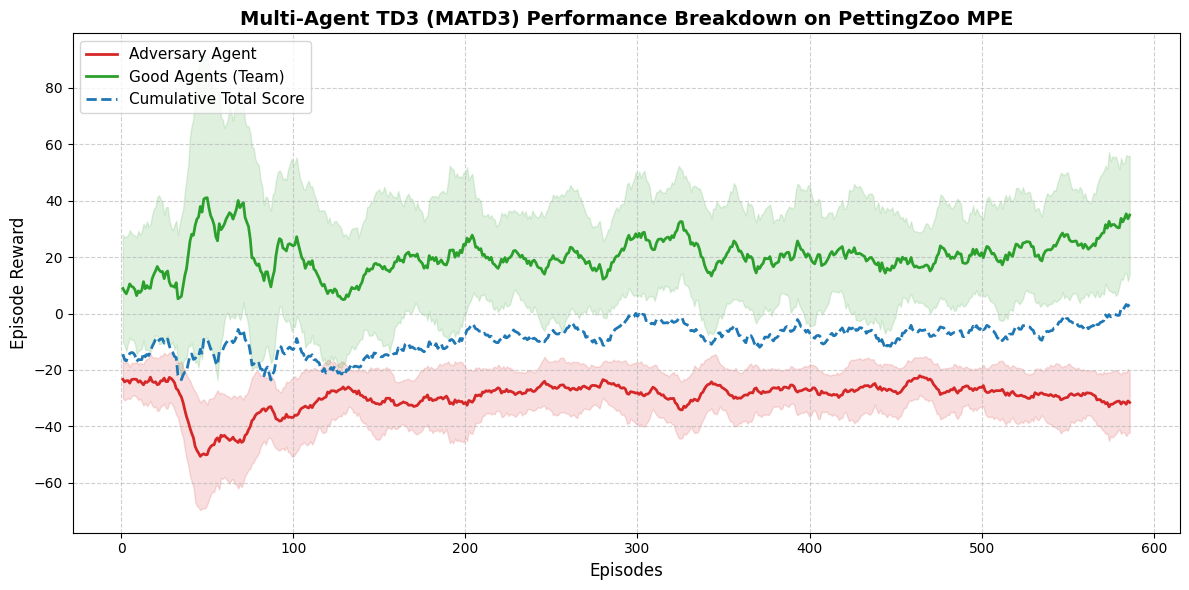

In [6]:
# Cell 6: Plotting Benchmarks with Confidence Intervals
def smooth(data, window=15):
    return np.convolve(data, np.ones(window)/window, mode='valid')

total_arr = np.array(all_seeds_total_rewards)
adv_arr = np.array(all_seeds_adversary_rewards)
good_arr = np.array(all_seeds_agents_rewards)

mean_total = smooth(np.mean(total_arr, axis=0))
std_total = smooth(np.std(total_arr, axis=0))

mean_adv = smooth(np.mean(adv_arr, axis=0))
std_adv = smooth(np.std(adv_arr, axis=0))

mean_good = smooth(np.mean(good_arr, axis=0))
std_good = smooth(np.std(good_arr, axis=0))

episodes = np.arange(1, len(mean_total) + 1)

plt.figure(figsize=(12, 6))

plt.plot(episodes, mean_adv, label='Adversary Agent', color='#d62728', linewidth=2)
plt.fill_between(episodes, mean_adv - std_adv, mean_adv + std_adv, color='#d62728', alpha=0.15)

plt.plot(episodes, mean_good, label='Good Agents (Team)', color='#2ca02c', linewidth=2)
plt.fill_between(episodes, mean_good - std_good, mean_good + std_good, color='#2ca02c', alpha=0.15)

plt.plot(episodes, mean_total, label='Cumulative Total Score', color='#1f77b4', linestyle='--', linewidth=2)

plt.title('Multi-Agent TD3 (MATD3) Performance Breakdown on PettingZoo MPE', fontsize=14, fontweight='bold')
plt.xlabel('Episodes', fontsize=12)
plt.ylabel('Episode Reward', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.savefig('matd3_benchmark_results.png', dpi=300)
plt.show()

GIF rendered successfully and saved to maddpg_project/renders/trained_agents.gif


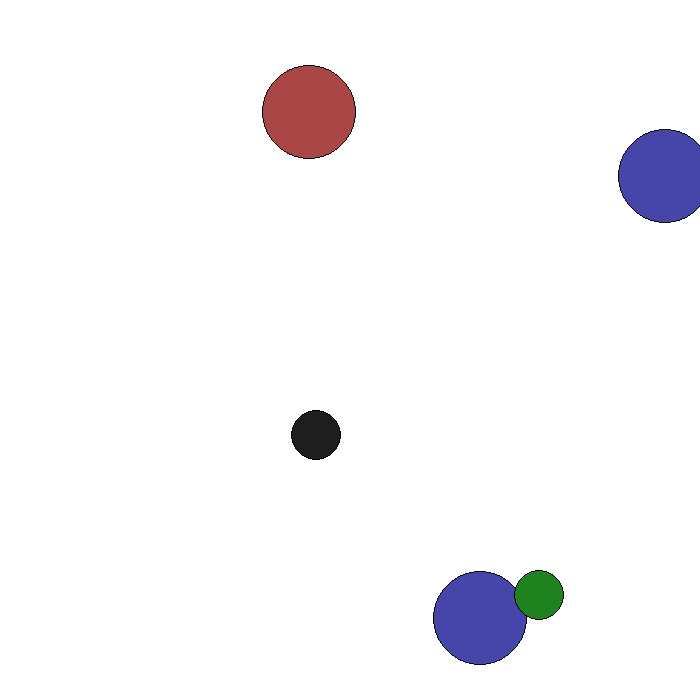

In [7]:
# Cell 7: Evaluation & Video Rendering
import imageio
from IPython.display import Image, display

eval_env = simple_adversary_v3.parallel_env(max_cycles=50, continuous_actions=True, render_mode="rgb_array")
obs_dict, _ = eval_env.reset(seed=42)
agents_list = eval_env.agents

eval_matd3 = MATD3(actor_dims, critic_dims, n_agents, n_actions, scenario=SCENARIO)
eval_matd3.load_models()

frames = []
obs = [obs_dict[agent] for agent in agents_list]

for step in range(50):
    frame = eval_env.render()
    frames.append(frame)

    actions_list = eval_matd3.choose_action(obs, evaluate=True)
    actions_dict = {agent: actions_list[idx] for idx, agent in enumerate(agents_list)}

    obs_dict_, rewards_dict, terminations, truncations, _ = eval_env.step(actions_dict)
    obs = [obs_dict_[agent] for agent in agents_list if agent in obs_dict_]

    if not eval_env.agents:
        break

eval_env.close()

gif_path = "maddpg_project/renders/trained_agents.gif"
imageio.mimsave(gif_path, frames, fps=15)
print(f"GIF rendered successfully and saved to {gif_path}")

display(Image(filename=gif_path))

# New section

In [8]:
!find maddpg_project -maxdepth 3 -type f

maddpg_project/src/buffers/buffer.py
maddpg_project/src/networks/networks.py
maddpg_project/src/agents/matd3.py
maddpg_project/saved_models/agent_0_critic
maddpg_project/saved_models/agent_1_critic
maddpg_project/saved_models/agent_0_actor
maddpg_project/saved_models/agent_1_actor
maddpg_project/saved_models/agent_2_actor
maddpg_project/saved_models/agent_2_critic
maddpg_project/renders/trained_agents.gif


In [9]:
!zip -r maddpg_project.zip maddpg_project

  adding: maddpg_project/ (stored 0%)
  adding: maddpg_project/src/ (stored 0%)
  adding: maddpg_project/src/buffers/ (stored 0%)
  adding: maddpg_project/src/buffers/buffer.py (deflated 76%)
  adding: maddpg_project/src/buffers/__pycache__/ (stored 0%)
  adding: maddpg_project/src/buffers/__pycache__/buffer.cpython-313.pyc (deflated 57%)
  adding: maddpg_project/src/networks/ (stored 0%)
  adding: maddpg_project/src/networks/networks.py (deflated 76%)
  adding: maddpg_project/src/networks/__pycache__/ (stored 0%)
  adding: maddpg_project/src/networks/__pycache__/networks.cpython-313.pyc (deflated 64%)
  adding: maddpg_project/src/agents/ (stored 0%)
  adding: maddpg_project/src/agents/matd3.py (deflated 74%)
  adding: maddpg_project/src/agents/__pycache__/ (stored 0%)
  adding: maddpg_project/src/agents/__pycache__/matd3.cpython-313.pyc (deflated 53%)
  adding: maddpg_project/src/utils/ (stored 0%)
  adding: maddpg_project/saved_models/ (stored 0%)
  adding: maddpg_project/saved_model